In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from skimage.io import imread
from skimage.restoration import rolling_ball
from os.path import join
import tifffile

dirpath      = r'E:\ND2\4_GFAP_IBA1\tiff_SC'
filename     = r'P50_SC_116_4_40X_loc02.tif'
filepath     = join(dirpath, filename)
img  = imread(filepath)

with tifffile.TiffFile(filepath) as tif:
    luts = tif.imagej_metadata['LUTs']

def lut_color(lut):
    r, g, b = lut[0].sum(), lut[1].sum(), lut[2].sum()
    if r == 0 and g > 0 and b > 0: return 'CYAN'   # GFAP 647
    elif r > 0 and g == 0 and b == 0: return 'Red'   # IBA1 555
    elif r == 0 and g > 0 and b == 0: return 'Green'
    elif r == 0 and g == 0 and b > 0: return 'BLUE' # DAPI
    else: return None

channel_colors = [lut_color(lut) for lut in luts]
print(channel_colors)

['CYAN', 'Red', 'Green', 'BLUE']


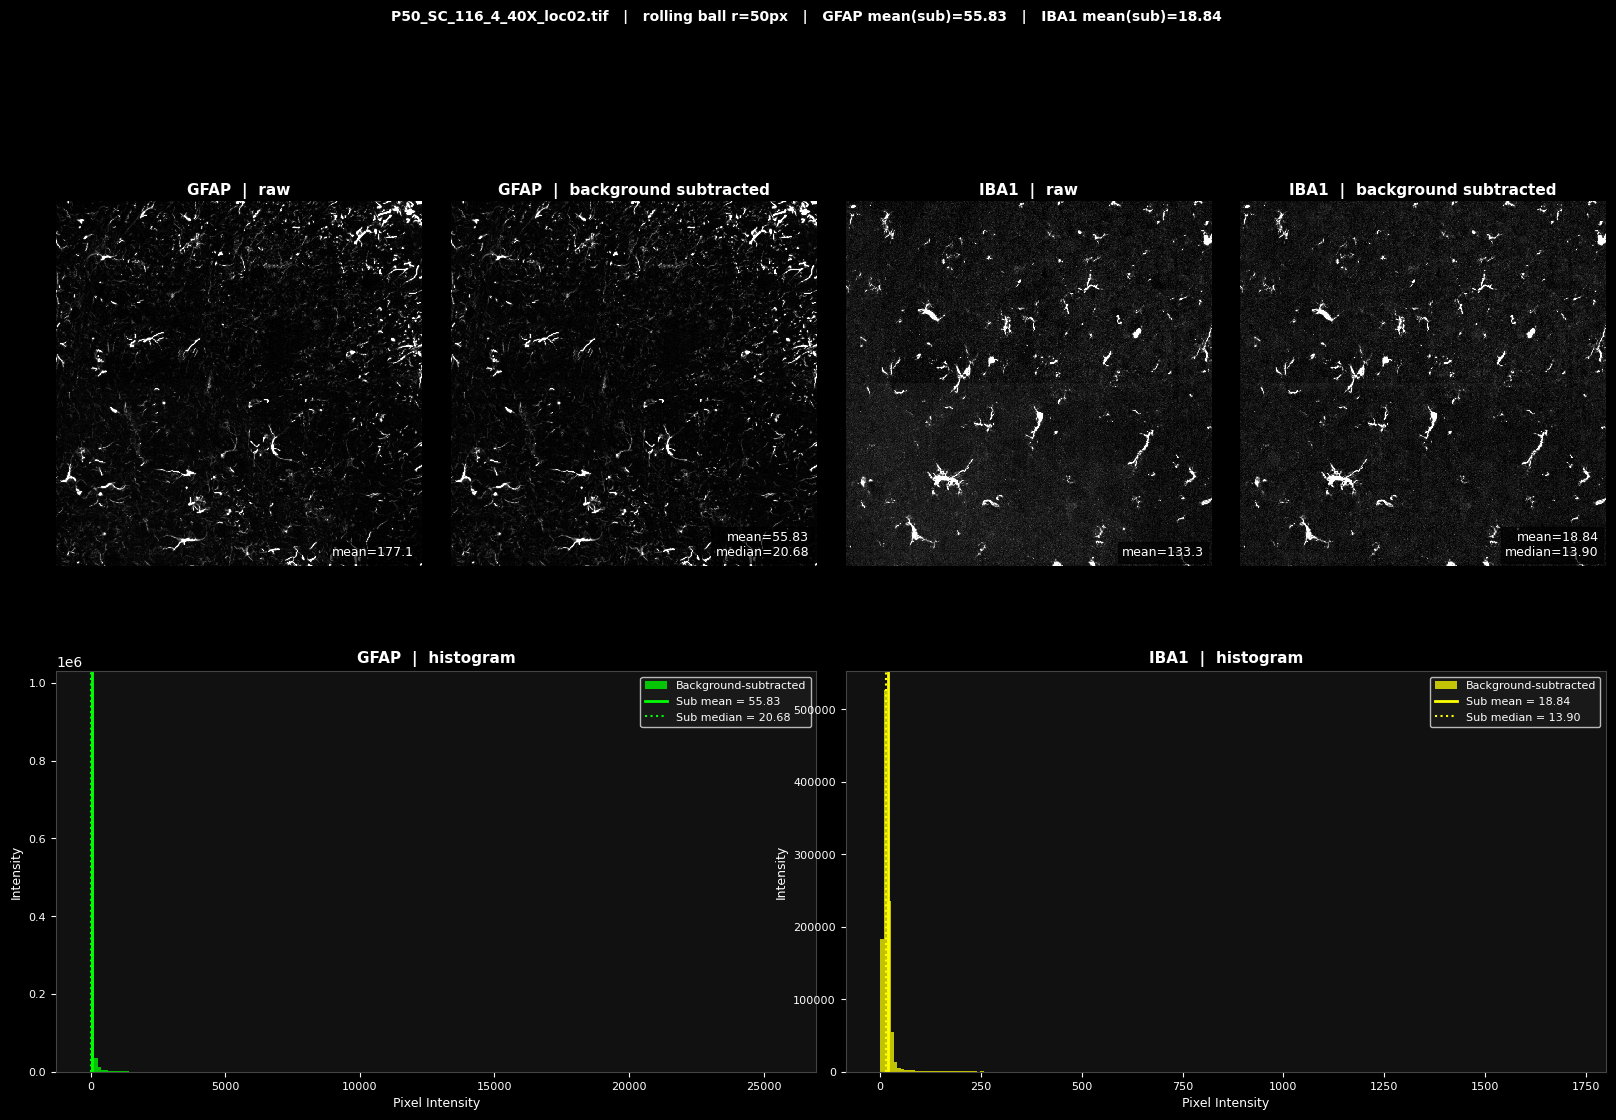

P50_SC_116_4_40X_loc02.tif ||  
GFAP  raw=177.1  sub_mean=55.83  sub_median=20.68  ||  IBA1  raw=133.3  sub_mean=18.84  sub_median=13.90


In [8]:
GFAP_CHANNEL = channel_colors.index('CYAN')
IBA1_CHANNEL = channel_colors.index('Red')
BALL_RADIUS  = 50

gfap_raw = img[:, :, GFAP_CHANNEL].astype(np.float32)
iba1_raw = img[:, :, IBA1_CHANNEL].astype(np.float32)

# ─────────────────────────────────────────────
# ROLLING BALL BACKGROUND SUBTRACTION
# ─────────────────────────────────────────────
def subtract_background(channel, radius=50):
    background = rolling_ball(channel, radius=radius)
    subtracted = np.clip(channel - background, 0, None)
    return subtracted

gfap_sub = subtract_background(gfap_raw, BALL_RADIUS)
iba1_sub = subtract_background(iba1_raw, BALL_RADIUS)

def compute_stats(raw, subtracted):
    return {
        'mean_raw':    float(raw.mean()),
        'mean_sub':    float(subtracted.mean()),
        'median_sub':  float(np.median(subtracted)),
    }

g = compute_stats(gfap_raw, gfap_sub)
i = compute_stats(iba1_raw, iba1_sub)

# ─────────────────────────────────────────────
# FIGURE
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor('black')
gs  = gridspec.GridSpec(2, 4, hspace=0.12, wspace=0.08,
                        height_ratios=[1, 0.85])

def styled_ax(ax):
    ax.set_facecolor('#111111')
    ax.tick_params(colors='white', labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#444444')
    return ax

for col_offset, (marker, raw, sub, stats, pos_color) in enumerate([
        ('GFAP', gfap_raw, gfap_sub, g, 'lime'),
        ('IBA1', iba1_raw, iba1_sub, i, 'yellow')]):

    c        = col_offset * 2
    vmin_raw = np.percentile(raw, 1)
    vmax_raw = np.percentile(raw, 99)
    vmin_sub = np.percentile(sub, 1)
    vmax_sub = np.percentile(sub, 99)

    # ── Raw image ──
    ax_raw = fig.add_subplot(gs[0, c])
    ax_raw.set_facecolor('black')
    ax_raw.imshow(raw, cmap='gray', interpolation='none', vmin=vmin_raw, vmax=vmax_raw)
    ax_raw.set_title(f'{marker}  |  raw', color='white', fontsize=11, fontweight='bold', pad=4)
    ax_raw.text(0.98, 0.02, f"mean={stats['mean_raw']:.1f}",
                transform=ax_raw.transAxes, fontsize=9, color='white',
                va='bottom', ha='right',
                bbox=dict(facecolor='black', alpha=0.7, pad=3))
    ax_raw.axis('off')

    # ── Background-subtracted image ──
    ax_sub = fig.add_subplot(gs[0, c+1])
    ax_sub.set_facecolor('black')
    ax_sub.imshow(sub, cmap='gray', interpolation='none', vmin=vmin_sub, vmax=vmax_sub)
    ax_sub.set_title(f'{marker}  |  background subtracted', color='white',
                     fontsize=11, fontweight='bold', pad=4)
    ax_sub.text(0.98, 0.02,
                f"mean={stats['mean_sub']:.2f}\nmedian={stats['median_sub']:.2f}",
                transform=ax_sub.transAxes, fontsize=9, color='white',
                va='bottom', ha='right',
                bbox=dict(facecolor='black', alpha=0.7, pad=3))
    ax_sub.axis('off')

    # ── Histogram ──
    ax_hist = styled_ax(fig.add_subplot(gs[1, c:c+2]))
    ax_hist.hist(sub.ravel(), bins=200, color=pos_color, alpha=0.75,
                 label='Background-subtracted', density=False)
    ax_hist.axvline(stats['mean_sub'], color=pos_color, linestyle='-', linewidth=2,
                    label=f"Sub mean = {stats['mean_sub']:.2f}")
    ax_hist.axvline(stats['median_sub'], color=pos_color, linestyle=':', linewidth=1.5,
                    label=f"Sub median = {stats['median_sub']:.2f}")
    ax_hist.set_xlabel('Pixel Intensity', color='white', fontsize=9)
    ax_hist.set_ylabel('Intensity',         color='white', fontsize=9)
    ax_hist.set_title(f'{marker}  |  histogram', color='white', fontsize=11, fontweight='bold')
    ax_hist.legend(fontsize=8, facecolor='#1a1a1a', labelcolor='white',
                   framealpha=0.9, loc='upper right')

fig.suptitle(
    f"{filename}   |   rolling ball r={BALL_RADIUS}px   |   "
    f"GFAP mean(sub)={g['mean_sub']:.2f}   |   "
    f"IBA1 mean(sub)={i['mean_sub']:.2f}",
    color='white', fontsize=10, fontweight='bold', y=0.995
)

out_path = join(dirpath, 'quantification.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='black')
plt.show()

# ─────────────────────────────────────────────
# FINAL SUMMARY LINE
# ─────────────────────────────────────────────
print(f"{filename} ||  "
    f"\nGFAP  raw={g['mean_raw']:.1f}  sub_mean={g['mean_sub']:.2f}  sub_median={g['median_sub']:.2f}  ||  "
    f"IBA1  raw={i['mean_raw']:.1f}  sub_mean={i['mean_sub']:.2f}  sub_median={i['median_sub']:.2f}"
)